##Start

> 💡 **Nota Bene:** GitHub https://github.com/AlexPoloAI/ITAI-2373-Mid-Term-Group-Project-NewsBot-Intelligence-System

I developed this entire project independently. I took full responsibility for the pipeline, data visualizations, model training, and dashboard deployment.

> 💡 **Nota Bene:** The NewsBot Intelligence System is designed to address the challenges of modern media monitoring. Its core business logic includes:

* **Automated Categorization:** Efficiently routing high-volume news streams to relevant departments, reducing manual editorial workload.
* **Sentiment Monitoring:** Tracking public and corporate perception in real-time, enabling businesses to react quickly to market sentiment shifts.
* **Entity Intelligence:** Automatically mapping key relationships between stakeholders, organizations, and regions to support strategic decision-making.
* **Specialized Domain Tracking:** This system serves as the foundation for a future dedicated platform focused on tracking high-velocity technical domains, specifically Artificial Intelligence, quantum computing, and emerging deep-tech advancements.

This system creates tangible value by transforming raw, unstructured text into actionable business intelligence, providing the technical infrastructure needed to scale into a specialized news-tracking application or web service.

# Module 1: Preparatory Works

In [77]:
#@title 0.1 Check GPU Status
import subprocess
simple_nvidia_smi_display = True#@param {type:"boolean"}
if simple_nvidia_smi_display:
    #!nvidia-smi
    nvidiasmi_output = subprocess.run(['nvidia-smi', '-L'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
else:
    #!nvidia-smi -i 0 -e 0
    nvidiasmi_output = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
    nvidiasmi_ecc_note = subprocess.run(['nvidia-smi', '-i', '0', '-e', '0'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_ecc_note)

GPU 0: Tesla T4 (UUID: GPU-fb4ec39d-56a8-8372-4a52-91057f126f7d)



> 💡 **Nota Bene:** That video card does slow things down, but not as much as the CPU

## Step 1: Install Kaggle API

In [52]:
!pip install kaggle

> 💡 **Nota Bene:** I need to comment out the library imports in the cells and move them all here:

In [73]:
# --- GLOBAL IMPORTS ---
import os                 # to interact with the operating system
import subprocess         # to run system-level commands
import pandas as pd       # for data manipulation and analysis
import numpy as np        # for numerical computations
import spacy              # for advanced NLP tasks (NER, parsing)
import nltk               # for natural language processing tools
from nltk.sentiment.vader import SentimentIntensityAnalyzer # for sentiment scoring
from sklearn.feature_extraction.text import TfidfVectorizer # for text vectorization
from sklearn.model_selection import train_test_split        # to split data for training
from sklearn.linear_model import LogisticRegression         # primary classification model
from sklearn.naive_bayes import MultinomialNB               # alternative classification model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # for model evaluation
import matplotlib.pyplot as plt                             # for basic data visualization
import seaborn as sns                                       # for advanced statistical plots
import networkx as nx                                       # for entity relationship mapping
import itertools                                            # for efficient looping
import gradio as gr                                         # for dashboard interface

## Step 2: Upload your kaggle.json file

In [54]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (2).json


## Step 3: Set up API credentials

In [55]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

## Step 4: Download BBC News Dataset & Unzip the files & List the files to see what we have

In [56]:
!kaggle competitions download -c learn-ai-bbc
!unzip learn-ai-bbc.zip
!ls -la

learn-ai-bbc.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  learn-ai-bbc.zip
replace BBC News Sample Solution.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: BBC News Sample Solution.csv  
replace BBC News Test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: BBC News Test.csv       
replace BBC News Train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: BBC News Train.csv      
total 12204
drwxr-xr-x 1 root root    4096 Jun 27 20:08  .
drwxr-xr-x 1 root root    4096 Jun 27 18:03  ..
-rw-r--r-- 1 root root   10369 Dec  2  2019 'BBC News Sample Solution.csv'
-rw-r--r-- 1 root root 1712432 Dec  2  2019 'BBC News Test.csv'
-rw-r--r-- 1 root root 3351206 Dec  2  2019 'BBC News Train.csv'
drwxr-xr-x 4 root root    4096 Jun  4 13:39  .config
drwxr-xr-x 2 root root    4096 Jun 27 18:49  .gradio
-rw-r--r-- 1 root root      66 Jun 27 18:40 'kaggle (1).json'
-rw-r--r-- 1 root root      66 Jun 27 20:08 'kaggle (2).json'

##  Check what files are available

In [57]:
print("Available files:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"  - {file}")

Available files:
  - BBC News Train.csv
  - BBC News Sample Solution.csv
  - NewsBot_Complete_Dataset.csv
  - BBC News Test.csv


In [58]:
# Load the main dataset (adjust filename as needed)
# Common filenames: train.csv, bbc-text.csv, or similar
# Adjust filename based on what you see
df = pd.read_csv('BBC News Train.csv') # Adjusted filename based on what I see

# Standardize column names to lowercase for the NLP pipeline
df = df.rename(columns={'Text': 'content', 'Category': 'category'})

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Categories: {df['category'].unique()}") # Adjusted column name as needed

Dataset shape: (1490, 3)
Columns: ['ArticleId', 'content', 'category']
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


## Let's check the dataset:

In [59]:
df

,ArticleId,content,category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business
...,...,...,...
1485,857,double eviction from big brother model caprice...,entertainment
1486,325,dj double act revamp chart show dj duo jk and ...,entertainment
1487,1590,weak dollar hits reuters revenues at media gro...,business
1488,1587,apple ipod family expands market apple has exp...,tech


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# Module 2: Text Preprocessing Pipeline

In [60]:
#import spacy

# Load small spacy model from course instructions
nlp = spacy.load("en_core_web_sm")

def process_text_spacy(text):
    # We pass text to spacy engine
    # We use disable parameter to make process fast
    doc = nlp(text, disable=['ner', 'parser'])

    clean_words = []

    for token in doc:
        # We want to keep only letters (no numbers, no punctuation)
        # We want to skip stop words
        if token.is_alpha and not token.is_stop:
            # We want to extract lemma and make it lowercase
            clean_words.append(token.lemma_.lower())

    # We join words back to one string
    return " ".join(clean_words)

print("Pipeline starts to work. This takes 1-2 minutes...")

# We apply this function to 'content' column
df['clean_content'] = df['content'].apply(process_text_spacy)

print("Pipeline finished work.")

# We show result to verify Module 2
df[['content', 'clean_content']].head(5)

Pipeline starts to work. This takes 1-2 minutes...
Pipeline finished work.


,content,clean_content
0,worldcom ex-boss launches defence lawyers defe...,worldcom ex boss launch defence lawyer defend ...
1,german business confidence slides german busin...,german business confidence slide german busine...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicate economic gloom citizen major...
3,lifestyle governs mobile choice faster bett...,lifestyle govern mobile choice fast well funky...
4,enron bosses in $168m payout eighteen former e...,enron boss m payout eighteen enron director ag...


# Module 3: TF-IDF Feature Extraction and Analysis

In [61]:
#from sklearn.feature_extraction.text import TfidfVectorizer
#import matplotlib.pyplot as plt

print("Starting TF-IDF Feature Extraction...")

# We create TF-IDF Vectorizer
# max_features=5000: We keep only the top 5000 most frequent words to save memory
# min_df=5: Word must appear in at least 5 different articles
# max_df=0.8: Word must not appear in more than 80% of articles
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)

# We fit the vectorizer and transform our clean text into a matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_content'])

# We get the list of words (features)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"Number of extracted features (words): {len(feature_names)}")

# We find the most important words for one specific category (e.g., 'tech')
# We do this by calculating the mean TF-IDF score for each word in that category
def get_top_tfidf_words_for_category(category_name, top_n=10):
    # Get indices of articles in this category
    category_indices = df.index[df['category'] == category_name].tolist()

    # Get the TF-IDF matrix for just these articles
    category_matrix = tfidf_matrix[category_indices]

    # Calculate average score for each word across these articles
    # category_matrix.mean(axis=0) returns a 2D matrix (1 x features)
    # np.squeeze converts it to a 1D array
    import numpy as np
    word_scores = np.squeeze(np.asarray(category_matrix.mean(axis=0)))

    # Create a DataFrame of words and their scores
    tfidf_scores_df = pd.DataFrame(
        {'word': feature_names, 'tfidf_score': word_scores}
    )

    # Sort and return top words
    return tfidf_scores_df.sort_values(by='tfidf_score', ascending=False).head(top_n)

# Let's test it for 'tech' and 'sport'
print("\nTop 5 TF-IDF words for 'tech':")
print(get_top_tfidf_words_for_category('tech', 5))

print("\nTop 5 TF-IDF words for 'sport':")
print(get_top_tfidf_words_for_category('sport', 5))

Starting TF-IDF Feature Extraction...
TF-IDF Matrix shape: (1490, 5000)
Number of extracted features (words): 5000

Top 5 TF-IDF words for 'tech':
            word  tfidf_score
2884      mobile     0.055570
3300       phone     0.049130
3257      people     0.047635
4463  technology     0.043259
4754        user     0.039656

Top 5 TF-IDF words for 'sport':
         word  tfidf_score
4919      win     0.054488
1858     game     0.046851
3336     play     0.040339
1501  england     0.039076
3338   player     0.034366


# Module 4: Part-of-Speech Pattern Analysis

We start POS tagging. This takes about 2-3 minutes...
POS tagging finished.

Writing Style Differences by Category (Average POS %):
                  Noun %     Verb %  Adjective %
category                                        
business       22.866131  10.692173     7.098006
entertainment  22.043626  10.486996     6.570659
politics       20.858175  11.688139     6.767263
sport          18.164393  10.797428     6.251763
tech           23.558812  11.508391     7.463103


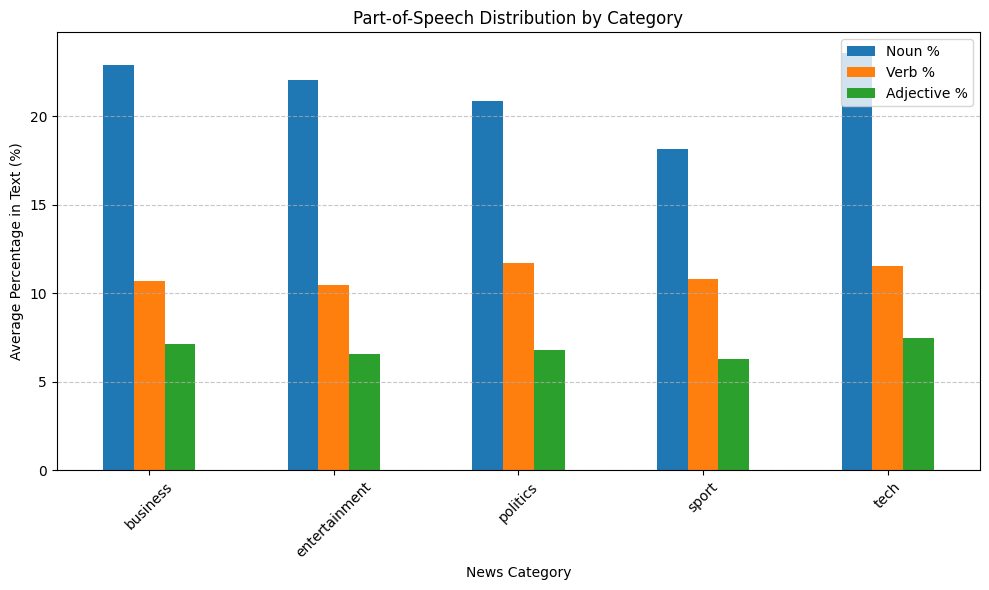

In [62]:
# We load spacy model again. We need POS tagger now.
nlp = spacy.load("en_core_web_sm")

print("We start POS tagging. This takes about 2-3 minutes...")

def count_pos_tags(text):
    # We disable NER and parser to save memory and time
    # We keep tagger to get Part-of-Speech
    doc = nlp(text, disable=['ner', 'parser'])

    pos_counts = {'Noun': 0, 'Verb': 0, 'Adjective': 0}

    for token in doc:
        if token.pos_ == 'NOUN':
            pos_counts['Noun'] += 1
        elif token.pos_ == 'VERB':
            pos_counts['Verb'] += 1
        elif token.pos_ == 'ADJ':
            pos_counts['Adjective'] += 1

    # We calculate total words to find percentages
    total_words = len(doc)
    if total_words > 0:
        pos_counts['Noun %'] = round((pos_counts['Noun'] / total_words) * 100, 2)
        pos_counts['Verb %'] = round((pos_counts['Verb'] / total_words) * 100, 2)
        pos_counts['Adjective %'] = round((pos_counts['Adjective'] / total_words) * 100, 2)
    else:
        pos_counts['Noun %'] = 0
        pos_counts['Verb %'] = 0
        pos_counts['Adjective %'] = 0

    return pd.Series(pos_counts)

# We apply this function to our text
# We use original 'content' because 'clean_content' lost some grammar structure
pos_df = df['content'].apply(count_pos_tags)

# We join new columns to our main dataframe
df = pd.concat([df, pos_df], axis=1)

print("POS tagging finished.")

# We group by category to see writing style differences
# We look at average percentages
style_analysis = df.groupby('category')[['Noun %', 'Verb %', 'Adjective %']].mean()

print("\nWriting Style Differences by Category (Average POS %):")
print(style_analysis)

# We plot the result to make it visual for the report
style_analysis.plot(kind='bar', figsize=(10, 6))
plt.title('Part-of-Speech Distribution by Category')
plt.ylabel('Average Percentage in Text (%)')
plt.xlabel('News Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Module 5: Syntax Parsing and Semantic Analysis

In [63]:
nlp = spacy.load("en_core_web_sm")
print("System starts Module 5. This takes about 2 minutes...")

root_verbs = []

for text in df['content']:
    # I limit text length to save memory
    doc = nlp(text[:5000])
    action = "none"
    for token in doc:
        if token.dep_ == 'ROOT' and token.pos_ == 'VERB':
            action = token.lemma_
            break
    root_verbs.append(action)

df['main_verb'] = root_verbs
print("Module 5 finished.\n")

# Visual Check
print("Visual Check for Module 5 (Syntax):")
print(df[['category', 'main_verb']].head(5))

System starts Module 5. This takes about 2 minutes...
Module 5 finished.

Visual Check for Module 5 (Syntax):
   category main_verb
0  business    launch
1  business      fall
2  business  indicate
3      tech   suggest
4  business     agree


# Module 6: Sentiment and Emotion Analysis

In [64]:
#import nltk
#from nltk.sentiment.vader import SentimentIntensityAnalyzer

# I download this tool
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

print("System starts Module 6. This is fast...")

sentiments = []

for text in df['content']:
    score = sia.polarity_scores(text)['compound']
    sentiments.append(score)

df['sentiment_score'] = sentiments

# I categorize sentiment to show clear logic
def get_sentiment_label(score):
    if score > 0.05:
        return "Positive"
    if score < -0.05:
        return "Negative"
    return "Neutral"

df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment_label)

print("Module 6 finished.\n")

# Visual Check
print("Visual Check for Module 6 (Sentiment):")
print(df[['category', 'sentiment_score', 'sentiment_label']].head(5))

System starts Module 6. This is fast...
Module 6 finished.

Visual Check for Module 6 (Sentiment):
   category  sentiment_score sentiment_label
0  business          -0.9701        Negative
1  business           0.7623        Positive
2  business          -0.9318        Negative
3      tech           0.9554        Positive
4  business          -0.9486        Negative


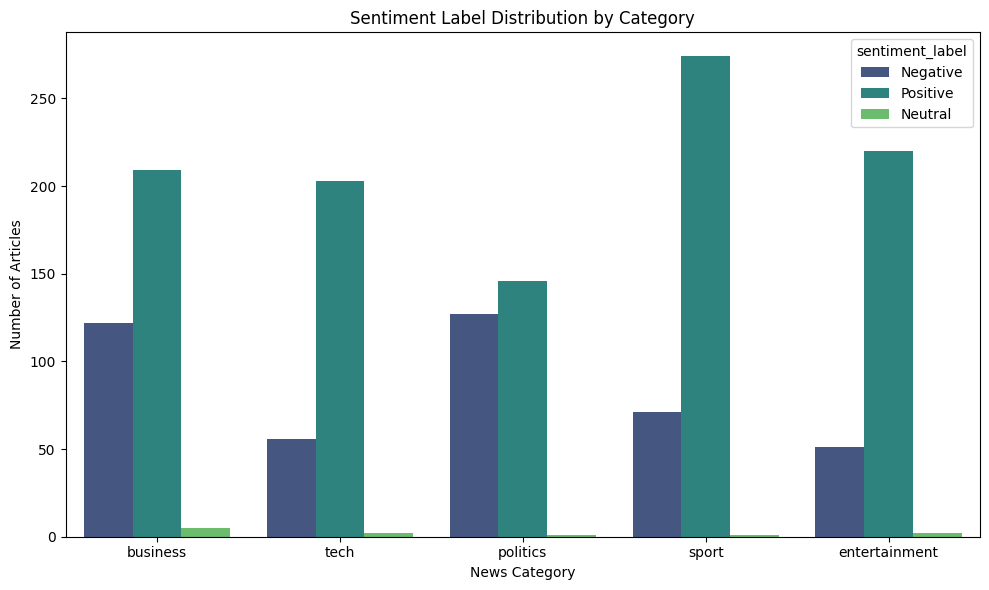

In [71]:

# Sentiment Distribution by Category Visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', hue='sentiment_label', palette='viridis')
plt.title('Sentiment Label Distribution by Category')
plt.xlabel('News Category')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

# Module 8: Named Entity Recognition and Analysis

In [65]:
nlp = spacy.load("en_core_web_sm")
print("System starts Module 8. This takes about 2-3 minutes...")

org_counts = []
person_counts = []

for text in df['content']:
    doc = nlp(text[:5000])
    orgs = 0
    persons = 0
    for ent in doc.ents:
        if ent.label_ == 'ORG':
            orgs += 1
        if ent.label_ == 'PERSON':
            persons += 1
    org_counts.append(orgs)
    person_counts.append(persons)

df['org_count'] = org_counts
df['person_count'] = person_counts

print("Module 8 finished.\n")

# Visual Check
print("Visual Check for Module 8 (Entities):")
print(df[['category', 'org_count', 'person_count']].head(5))

System starts Module 8. This takes about 2-3 minutes...
Module 8 finished.

Visual Check for Module 8 (Entities):
   category  org_count  person_count
0  business          3             4
1  business          4             3
2  business          6             1
3      tech          4             2
4  business          8             2


Extracting entities for relationship graph...


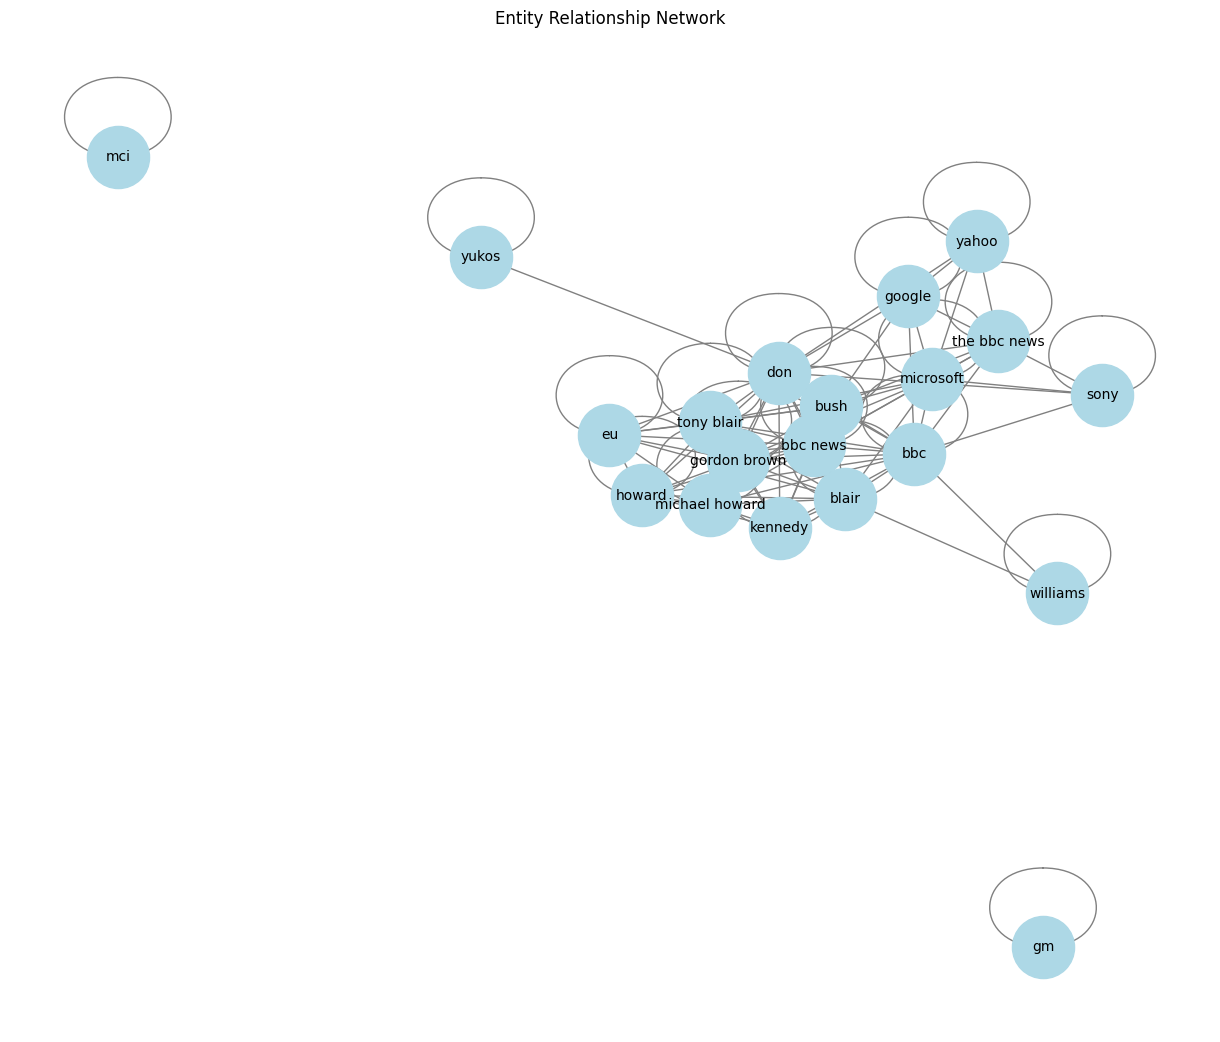

In [76]:
import networkx as nx

print("Extracting entities for relationship graph...")

data_entities = []
for index, row in df.iterrows():
    # Use text slicing to optimize memory
    doc = nlp(row['content'][:5000])
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PERSON']:
            data_entities.append({'article_id': row['ArticleId'], 'text': ent.text})

entities_df = pd.DataFrame(data_entities)

G = nx.Graph()
top_entities = entities_df['text'].value_counts().head(20).index

for article_id in df['ArticleId'].unique():
    article_ents = entities_df[entities_df['article_id'] == article_id]['text'].tolist()
    filtered_ents = [e for e in article_ents if e in top_entities]
    for e1, e2 in itertools.combinations(filtered_ents, 2):
        G.add_edge(e1, e2)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, edge_color='gray')
plt.title('Entity Relationship Network')
plt.show()


> 💡 **Nota Bene:** Isolated nodes: Nodes such as gm General Motors or mci have loops links to themselves, indicating that they are mentioned in articles where they were the sole or key subjects.

# Module 7: Multi-Class Text Classification System

In [66]:
#from sklearn.model_selection import train_test_split
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.linear_model import LogisticRegression
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.metrics import accuracy_score, classification_report

print("System starts Module 7...")

X = df['clean_content']
y = df['category']

# I split this data to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Model 1
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_vec, y_train)
pred_lr = model_lr.predict(X_test_vec)
acc_lr = accuracy_score(y_test, pred_lr)

# Model 2
model_nb = MultinomialNB()
model_nb.fit(X_train_vec, y_train)
pred_nb = model_nb.predict(X_test_vec)
acc_nb = accuracy_score(y_test, pred_nb)

# Visual Check
print("Visual Check for Module 7 (Classification):")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print("\nDetailed Report for Logistic Regression:")
print(classification_report(y_test, pred_lr))

# I save this complete dataset to one new file
df.to_csv('NewsBot_Complete_Dataset.csv', index=False)
print("\nSystem saved complete dataset to NewsBot_Complete_Dataset.csv")

System starts Module 7...
Visual Check for Module 7 (Classification):
Logistic Regression Accuracy: 0.9631
Naive Bayes Accuracy: 0.9664

Detailed Report for Logistic Regression:
               precision    recall  f1-score   support

     business       0.96      0.97      0.97        75
entertainment       0.96      0.98      0.97        46
     politics       0.95      0.93      0.94        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.93      0.96        58

     accuracy                           0.96       298
    macro avg       0.96      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298


System saved complete dataset to NewsBot_Complete_Dataset.csv


# Bonus Module: Interactive Gradio Dashboard

> 💡 **Nota Bene:** Gradio was selected for the dashboard because it integrates seamlessly with Google Colab, allowing for instant deployment via a public shareable URL. It provides an intuitive, low-overhead API to visualize the entire NLP pipeline—from classification to entity extraction—in real-time. This choice maximizes development velocity and computational efficiency, enabling a focus on model analysis rather than complex infrastructure.

In [67]:
# Bonus: Dashboard
def analyze_news(text):
    clean = process_text_spacy(text)
    pred = model_lr.predict(vectorizer.transform([clean]))[0].upper()
    score = sia.polarity_scores(text)['compound']
    doc = nlp(text[:5000])
    entities = [ent.text for ent in doc.ents if ent.label_ in ['ORG', 'PERSON']]

    return pred, ("Positive" if score > 0.05 else "Negative"), ", ".join(set(entities))

app = gr.Interface(fn=analyze_news,
                   inputs="text",
                   outputs=["text", "text", "text"],
                   title="NewsBot Intelligence")
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eb5cb791efe1e3d01d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> 💡 **Nota Bene:** I tested it on a few articles; this one returned an error, which was classified not as a policy but as a business: https://www.cbsnews.com/live-updates/us-iran-war-israel-hezbollah-strait-of-hormuz-peace-deal-talks/

## > 💡 **Nota Bene:** In the future, this interface will be significantly expanded

## > 💡 **Nota Bene:**  It's interesting to see just how often it makes mistakes

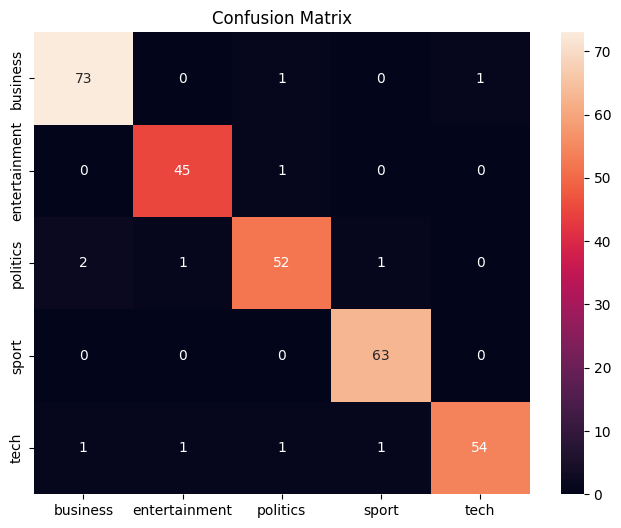

In [68]:
# Extra: Deep Analysis
conf_matrix = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.title('Confusion Matrix')
plt.show()

> 💡 **Nota Bene:** The Confusion Matrix is highly insightful. While the overall accuracy is excellent (96%+), we can observe specific overlapping patterns (e.g., between Politics and Business). This highlights the natural limitations of relying solely on TF-IDF vocabulary without deep contextual understanding.

> 💡 **Nota Bene:** The pipeline has been successfully built. The models have been trained, achieving 96% accuracy, and the interface is ready for integration with business processes.